# Continuing a calculation across a change of spin regime

An unpolarized run, a collinear one and a noncollinear one are three descriptions of the
same electrons, and the expensive part of all three, the charge density, is very nearly the
same object:

$$(n_\uparrow, n_\downarrow)
\;\longleftrightarrow\;
\big(n,\ m_z\big)
\;\longleftrightarrow\;
\big(n,\ \mathbf m\big),
\qquad
n = n_\uparrow + n_\downarrow, \quad m_z = n_\uparrow - n_\downarrow$$

So a converged calculation can start another one in a different regime: non-magnetic to
collinear, collinear to noncollinear, spin-orbit coupling switched on. What crosses is a
*guess*, so the continued run has to reach the same self-consistent solution as a fresh one,
and the saving is in how far it has to travel:

| case | fresh | continued | agreement |
|---|---|---|---|
| bcc Fe, `nspin` 2 to 4 with the moment rotated onto `x` | 27 iterations | **1** | 3e-8 Ry |
| bcc Fe, 1 to 2, magnetization seeded | 31 | 29 | 1e-9 Ry |
| Si, 2 to 4 | 5 | **1** | 1e-9 Ry |
| Pt, scalar PAW to fully relativistic PAW with `lspinorb` | 13 | **7** | 2e-10 Ry |

The first two run below; silicon and platinum are quoted, each costing a pair of
self-consistent runs of its own.

This is how a magnetic anisotropy is computed in practice: converge the collinear magnet
once, then run the noncollinear directions from it.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from defumat import Calculator

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite")
PSEUDO = Path("../tests/data/pseudo")

spinor = Calculator.from_file(QE / "pw_noncolin/noncolin.in", pseudo_dir=PSEUDO,
                              announce=False)
collinear = spinor.with_spin(2)
nonmagnetic = spinor.with_spin(1, starting_magnetization=(0.0,))
fe2 = collinear.get_scf()
print("bcc Fe, collinear:  E = %.8f Ry,  m = %.4f mu_B,  %d iterations"
      % (fe2.total_energy, fe2.magnetization, fe2.iterations))

bcc Fe, collinear:  E = -55.69968434 Ry,  m = 3.1758 mu_B,  31 iterations


`with_spin` is the whole of it: a new calculator in the target regime, holding this one's
converged state as its starting guess. The k-points are rebuilt rather than relabelled,
because the spin degeneracy factor and the magnetic symmetry group both change with the
regime.

The cell is QE's bcc iron with `angle1 = 90`, so the noncollinear run wants its moment along
$x$ while the collinear one can only put it on $z$. Rotating it is all the promotion has to
do, and the iteration count is what says so.

In [2]:
fresh = spinor.get_scf()
continued = spinor.get_scf(starting_from=fe2)

print("noncollinear from the atoms   %.8f Ry   %2d iterations"
      % (fresh.total_energy, fresh.iterations))
print("noncollinear continued        %.8f Ry   %2d iterations"
      % (continued.total_energy, continued.iterations))
print("difference                    %+.1e Ry"
      % (continued.total_energy - fresh.total_energy))
print("\nm:  collinear |m| = %.4f mu_B  ->  noncollinear (%.4f, %.4f, %.4f)"
      % ((fe2.magnetization,) + tuple(continued.magnetization_vector)))

noncollinear from the atoms   -55.69968434 Ry   27 iterations
noncollinear continued        -55.69968431 Ry    1 iterations
difference                    +3.0e-08 Ry

m:  collinear |m| = 3.1758 mu_B  ->  noncollinear (3.1759, 0.0000, -0.0000)


Twenty-seven iterations become one, and the two land on the same energy. Rotating a moment
costs nothing here because without spin-orbit coupling the energy does not depend on which
way it points; switch the coupling on and it does, by a fraction of a milli-Rydberg, and
this is exactly the starting point a magnetic anisotropy calculation needs.

## The other direction, where the moment has to be found

Non-magnetic to collinear is the hard one, because what crosses is the charge and the charge
was never the difficulty. The moment is, and an unpolarized run has none of it to give.

In [3]:
from defumat.scf import continued_state    # no facade route to an unseeded promotion

fe1 = nonmagnetic.get_scf()
seeded = collinear.get_scf(starting_from=fe1)
unseeded = collinear.get_scf(
    starting_from=continued_state(fe1, collinear.calculation, magnetization="none"))

print("non-magnetic  %.8f Ry  %2d iterations" % (fe1.total_energy, fe1.iterations))
print("seeded        %.8f Ry  %2d iterations,  m = %.4f mu_B"
      % (seeded.total_energy, seeded.iterations, seeded.magnetization))
print("unseeded      %.8f Ry  %2d iterations,  m = %.4f mu_B   <- unpolarized again"
      % (unseeded.total_energy, unseeded.iterations, unseeded.magnetization))
print("\nseeded against a fresh collinear run   %+.1e Ry"
      % (seeded.total_energy - fe2.total_energy))
print("magnetic stabilisation energy         %.6f Ry"
      % (seeded.total_energy - fe1.total_energy))

non-magnetic  -55.67804951 Ry  17 iterations
seeded        -55.69968434 Ry  29 iterations,  m = 3.1763 mu_B
unseeded      -55.67804951 Ry   1 iterations,  m = 0.0000 mu_B   <- unpolarized again

seeded against a fresh collinear run   -1.6e-09 Ry
magnetic stabilisation energy         -0.021635 Ry


**Nothing in the self-consistent loop breaks spin symmetry on its own.** Hand a collinear
run two identical channels and it converges, correctly reporting convergence, straight back
to the unpolarized state, which is a stationary point of the polarized functional and not
its minimum. The magnetization has to be put in by hand, exactly as `starting_magnetization`
puts it into a run started from the atoms, and that is what the promotion does when the
source has none. The energy it buys is the magnetic stabilisation energy of bcc iron, from
two runs of the same cell.

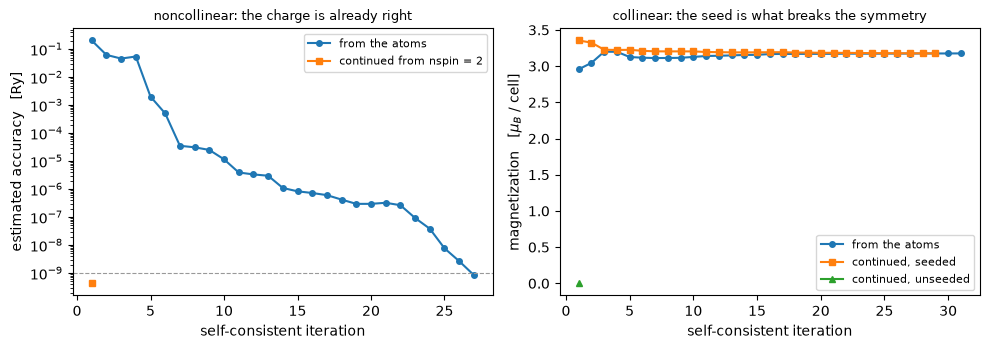

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.6))

for label, result, style in (("from the atoms", fresh, "-o"),
                             ("continued from nspin = 2", continued, "-s")):
    axes[0].semilogy([e["iteration"] for e in result.history],
                     [e["accuracy"] for e in result.history], style, ms=4, label=label)
axes[0].axhline(1e-9, color="0.6", lw=0.8, ls="--")
axes[0].set_ylabel("estimated accuracy   [Ry]")
axes[0].set_title("noncollinear: the charge is already right", fontsize=9)

for label, result, style in (("from the atoms", fe2, "-o"),
                             ("continued, seeded", seeded, "-s"),
                             ("continued, unseeded", unseeded, "-^")):
    axes[1].plot([e["iteration"] for e in result.history],
                 [e.get("magnetization", 0.0) for e in result.history],
                 style, ms=4, label=label)
axes[1].set_ylabel(r"magnetization   [$\mu_B$ / cell]")
axes[1].set_title("collinear: the seed is what breaks the symmetry", fontsize=9)

for ax in axes:
    ax.set_xlabel("self-consistent iteration")
    ax.legend(fontsize=8)
fig.tight_layout()

Left: the continued noncollinear run starts eight orders of magnitude closer than the atomic
guess and is finished in one step. Right: the same continuation from non-magnetic to
collinear saves two iterations out of thirty-one, because what it carries, the charge, was
never the hard part; both runs already have most of the moment after one iteration and then
spend thirty refining a density around it. The single point at zero is the unseeded run,
which starts on the symmetric solution, finds it stationary, and stops.

## What it refuses

A promotion is refused rather than approximated wherever the target asks for something the
source cannot say. A collinear source carries **one scalar field**, so a target whose species
point their moments in different directions is refused, and seeding it explicitly is the way
out. A genuinely noncollinear magnetization cannot be **split back** into two collinear
channels. A Hubbard `U` cannot cross into `nspin = 4`, its occupation matrix having no
noncollinear form here. And a `becsum` from a **different pseudopotential** is dropped with a
warning rather than reshaped, which is what happens when spin-orbit coupling is switched on:
the fully relativistic dataset has different projectors, so the density crosses and the
augmentation occupations do not.

---
The tests behind this notebook: `tests/regression/test_continuation.py`, which runs all four
cases of the table above, including the silicon and platinum pairs quoted here; and
`tests/unit/test_continuation_machinery.py`, which holds the charge-and-moment round trip,
the rotation onto the target's axis, and each of the refusals.